In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga y Extracción de Variables Temporales

In [2]:
# 1. Cargar la muestra optimizada
print("Cargando dataset...")
df = pd.read_csv('../datos/01_dataset_limpio_y_unificado.csv.gz')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Ingeniería de Características (Feature Engineering)
# Extraemos la hora (0-23) y el día de la semana (0=Lunes, 6=Domingo)
df['hora'] = df['timestamp'].dt.hour
df['dia_semana'] = df['timestamp'].dt.dayofweek
df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6]) # True si es Sábado o Domingo

# Métrica de consumo relativo por m²
df['kwh_per_sqm'] = df['kwh'] / df['sqm']

print(f"Dataset preparado para detección de anomalías. Filas: {df.shape[0]:,}")

Cargando dataset...
Dataset preparado para detección de anomalías. Filas: 5,314,912


## Cazando el "Desperdicio Fantasma" (Gráfico de Anomalías)
En las oficinas y facultades de los campus, el consumo los fines de semana debería desplomarse porque no hay clases ni actividad administrativa. Si un edificio mantiene el aire acondicionado o las luces a tope un domingo a las 3 de la mañana, tenemos una anomalía de gestión.

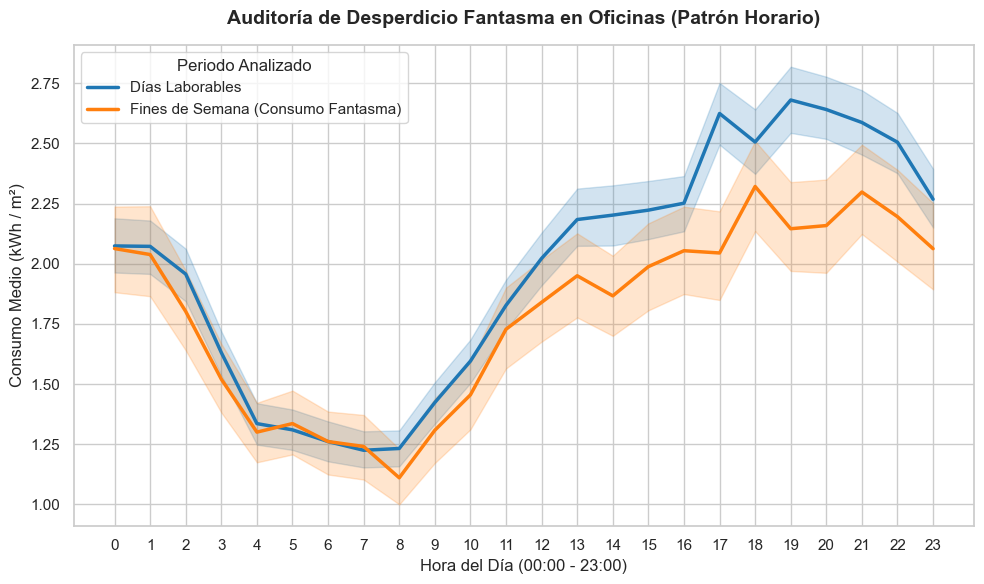

¡Gráfico de anomalías corregido y guardado con éxito!


In [9]:
# Filtrar solo oficinas para hacer una auditoría homogénea
df_oficinas = df[df['primaryspaceusage'] == 'Office'].copy()

# Configurar el lienzo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Pintar el patrón de consumo por horas
# Quitamos el parámetro 'legend' de aquí para controlarlo nosotros manualmente abajo
sns.lineplot(
    data=df_oficinas, 
    x='hora', 
    y='kwh_per_sqm', 
    hue='es_fin_de_semana', 
    palette={False: '#1f77b4', True: '#ff7f0e'}, # Azul laborables, Naranja fin de semana
    linewidth=2.5,
    legend=False 
)

# PERSONALIZACIÓN MANUAL DE LA LEYENDA (La corrección clave)
from matplotlib.lines import Line2D
elementos_leyenda = [
    Line2D([0], [0], color='#1f77b4', lw=2.5, label='Días Laborables'),
    Line2D([0], [0], color='#ff7f0e', lw=2.5, label='Fines de Semana (Consumo Fantasma)')
]
plt.legend(handles=elementos_leyenda, title='Periodo Analizado', fontsize=11, title_fontsize=12, loc='upper left')

# Personalizar etiquetas para la entrega
plt.title('Auditoría de Desperdicio Fantasma en Oficinas (Patrón Horario)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Hora del Día (00:00 - 23:00)', fontsize=12)
plt.ylabel('Consumo Medio (kWh / m²)', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()

# Guardar el gráfico de anomalías corregido
plt.savefig('../graficos/04_auditoria_anomalias_horarias.png', dpi=300)
plt.show()

print("¡Gráfico de anomalías corregido y guardado con éxito!")

## TOP 5 Edificios con mayor consumo fantasma (Domingos)

In [5]:
# 1. Filtrar solo las lecturas de OFICINAS que ocurren los DOMINGOS (dia_semana == 6)
df_domingos = df_oficinas[df_oficinas['dia_semana'] == 6].copy()

# 2. Agrupar por el ID del edificio y calcular el consumo medio por metro cuadrado
ranking_desperdicio = df_domingos.groupby('building_id')['kwh_per_sqm'].mean().reset_index()

# 3. Ordenar de mayor a menor y quedarnos con los 5 peores
top_5_ineficientes = ranking_desperdicio.sort_values(by='kwh_per_sqm', ascending=False).head(5)

# Formatear el resultado visual convirtiendo los números a formato legible con puntos
print("="*65)
print("   TOP 5: EDIFICIOS DE OFICINAS CON MAYOR CONSUMO FANTASMA (DOMINGOS)")
print("="*65)
for i, row in enumerate(top_5_ineficientes.itertuples(), 1):
    consumo_formateado = f"{row.kwh_per_sqm:.4f}".replace(".", ",")
    print(f"{i}. Edificio: {row.building_id:<30} | Consumo Medio: {consumo_formateado} kWh/m²")
print("="*65)

   TOP 5: EDIFICIOS DE OFICINAS CON MAYOR CONSUMO FANTASMA (DOMINGOS)
1. Edificio: Eagle_office_Phyllis           | Consumo Medio: 25,7095 kWh/m²
2. Edificio: Eagle_office_Mandi             | Consumo Medio: 24,4000 kWh/m²
3. Edificio: Eagle_office_Lamont            | Consumo Medio: 21,3363 kWh/m²
4. Edificio: Eagle_office_Norbert           | Consumo Medio: 20,4037 kWh/m²
5. Edificio: Eagle_office_Jeff              | Consumo Medio: 20,2310 kWh/m²


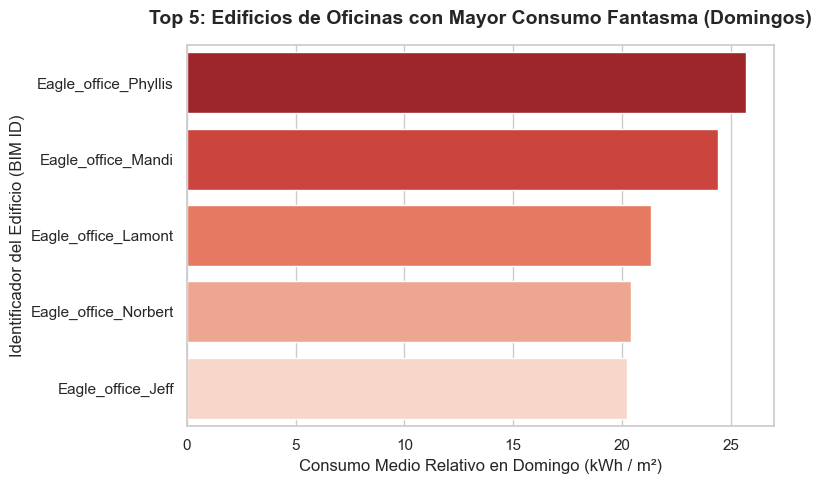

¡Gráfico 05 (Ranking de Ineficiencia) generado y guardado en la carpeta 'graficos'!


In [8]:
# 1. Calcular el ranking de desperdicio de oficinas los domingos
df_domingos = df_oficinas[df_oficinas['dia_semana'] == 6].copy()
ranking_desperdicio = df_domingos.groupby('building_id')['kwh_per_sqm'].mean().reset_index()

# Quedarnos con los 5 peores edificios
top_5_ineficientes = ranking_desperdicio.sort_values(by='kwh_per_sqm', ascending=False).head(5)

# 2. Configurar el lienzo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras horizontales utilizando la paleta cálida 'Reds_r' (para indicar alerta/ineficiencia)
sns.barplot(
    data=top_5_ineficientes, 
    x='kwh_per_sqm', 
    y='building_id', 
    palette='Reds_r', 
    hue='building_id', 
    legend=False
)

# 3. Personalización técnica del gráfico para la entrega
plt.title('Top 5: Edificios de Oficinas con Mayor Consumo Fantasma (Domingos)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Consumo Medio Relativo en Domingo (kWh / m²)', fontsize=12)
plt.ylabel('Identificador del Edificio (BIM ID)', fontsize=12)
plt.tight_layout()

# GUARDAR EL GRÁFICO AUTOMÁTICAMENTE para tu presentación PowerPoint
plt.savefig('../graficos/05_ranking_consumo_fantasma.png', dpi=300)
plt.show()

print("¡Gráfico 05 (Ranking de Ineficiencia) generado y guardado en la carpeta 'graficos'!")